# When Randomness Met Calculus: A Practitioner's Guide to Stochastic Differential Equations

**Blog post:** [thedataguy.pro/blog/2026/04/stochastic-differential-equations-practitioners-guide](https://thedataguy.pro/blog/2026/04/stochastic-differential-equations-practitioners-guide/)  
**Author:** Muhammad Afzaal — [mo@thedataguy.pro](mailto:mo@thedataguy.pro)  
**Series:** Monte Carlo Methods — Part 3

---

This notebook accompanies the blog post and contains all runnable Python code.
It covers:

1. **The Euler-Maruyama solver** — a generic, reusable SDE simulator
2. **System 1 — Ornstein-Uhlenbeck** (Physics: particle in a fluid)
3. **System 2 — Stochastic Logistic Growth** (Biology: population dynamics)
4. **System 3 — Geometric Brownian Motion** (Finance: asset prices)
5. **Convergence analysis** — verifying O(√Δt) behaviour

### Requirements

To setup environment and install required execute `uv sync` and instruction as follow to setup UV

> 📦 [uv install guide](https://docs.astral.sh/uv/guides/install-python/)  OR checkout [Best of both worlds](https://thedataguy.pro/blog/2025/06/best-of-both-worlds/)


In [ ]:
# 📦 Install required packages
# !pip install install numpy matplotlib scipy

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from typing import Callable

# Use a clean style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

print('Libraries loaded ✓')

Libraries loaded ✓


---
## 1. The Euler-Maruyama Solver

The general Itô SDE:

$$dX = \mu(X, t)\, dt + \sigma(X, t)\, dW$$

is discretized as:

$$X_{n+1} = X_n + \mu(X_n, t_n)\,\Delta t + \sigma(X_n, t_n)\,\sqrt{\Delta t}\, Z_n, \quad Z_n \sim \mathcal{N}(0,1)$$

The key insight: the noise term shrinks as **√Δt** (not Δt), because the variance of a Wiener increment equals the time elapsed.

In [11]:
def euler_maruyama(
    drift: Callable[[np.ndarray, float], np.ndarray],
    diffusion: Callable[[np.ndarray, float], np.ndarray],
    x0: float,
    t_start: float,
    t_end: float,
    dt: float,
    n_paths: int = 1,
    seed: int | None = None
) -> tuple[np.ndarray, np.ndarray]:
    """
    Simulate an Itô SDE using the Euler-Maruyama method.

    dX = drift(X, t) dt + diffusion(X, t) dW

    Parameters
    ----------
    drift       : function(X, t) -> array  —  the μ(X,t) term
    diffusion   : function(X, t) -> array  —  the σ(X,t) term
    x0          : initial state X(t_start)
    t_start     : start time
    t_end       : end time
    dt          : time step size (smaller = more accurate)
    n_paths     : number of independent sample paths to simulate
    seed        : optional random seed for reproducibility

    Returns
    -------
    t           : 1D array of time points, shape (N+1,)
    X           : 2D array of paths, shape (n_paths, N+1)
    """
    if seed is not None:
        np.random.seed(seed)

    t = np.arange(t_start, t_end + dt, dt)
    N = len(t)
    X = np.zeros((n_paths, N))
    X[:, 0] = x0

    sqrt_dt = np.sqrt(dt)

    for i in range(N - 1):
        x_current = X[:, i]
        t_current = t[i]

        # Draw n_paths standard normal random variables at once (vectorised)
        Z = np.random.standard_normal(n_paths)

        # Euler-Maruyama step
        X[:, i + 1] = (
            x_current
            + drift(x_current, t_current) * dt
            + diffusion(x_current, t_current) * sqrt_dt * Z
        )

    return t, X

print('Euler-Maruyama solver defined ✓')

Euler-Maruyama solver defined ✓


---
## 2. System 1 — Physics: Ornstein-Uhlenbeck Process

**Models:** a particle in a viscous fluid (Robert Brown's pollen!)

$$dX = \theta(\mu_0 - X)\, dt + \sigma\, dW$$

| Symbol | Meaning |
|--------|---------|
| $\theta$ | Mean-reversion rate — how fast the particle returns to equilibrium |
| $\mu_0$ | Equilibrium position |
| $\sigma$ | Thermal noise strength |

This is the **simplest mean-reverting SDE**: the particle is constantly pulled back to $\mu_0$ by friction, while thermal kicks keep it bouncing around.

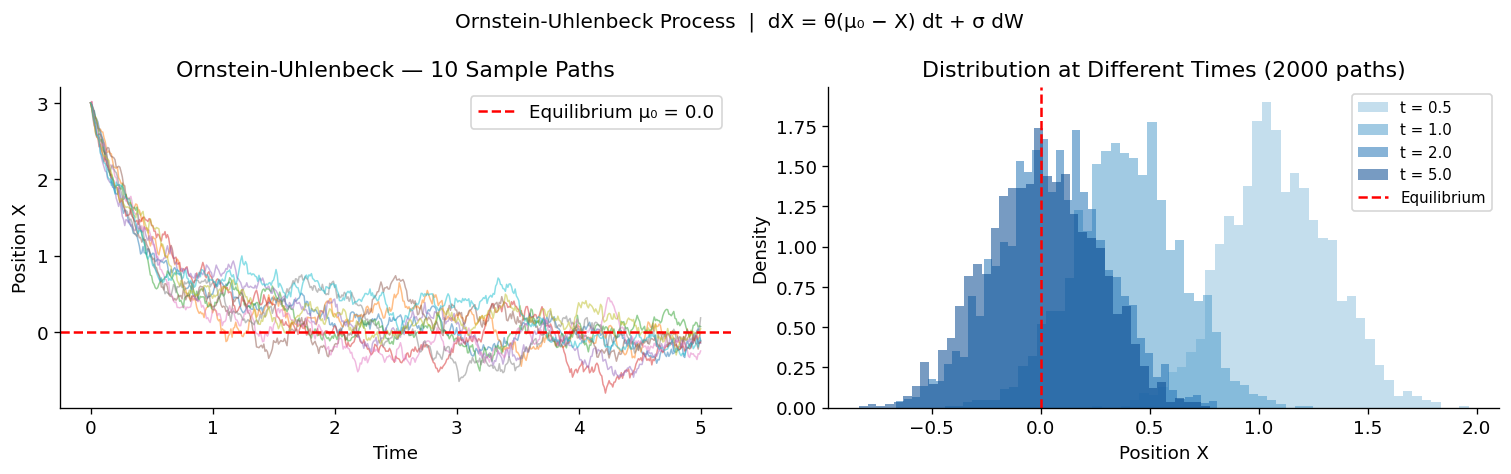

At t=5.0: mean = -0.0029  (theoretical: 0.0)
At t=5.0: std  = 0.2535  (theoretical: 0.2500)


In [12]:
# --- OU Process parameters ---
theta = 2.0    # mean reversion rate (particle returns to centre in ~1/θ = 0.5 time units)
mu_0  = 0.0    # equilibrium position
sigma = 0.5    # thermal noise strength

def ou_drift(x, t):
    return theta * (mu_0 - x)

def ou_diffusion(x, t):
    return sigma  # constant: noise is independent of position

# Simulate 10 paths
t_ou, X_ou = euler_maruyama(
    drift=ou_drift,
    diffusion=ou_diffusion,
    x0=3.0,       # particle starts far from equilibrium
    t_start=0.0,
    t_end=5.0,
    dt=0.01,
    n_paths=10,
    seed=42
)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: sample paths
for path in X_ou:
    axes[0].plot(t_ou, path, alpha=0.5, linewidth=0.9)
axes[0].axhline(mu_0, color='red', linestyle='--', linewidth=1.5, label=f'Equilibrium μ₀ = {mu_0}')
axes[0].set_title('Ornstein-Uhlenbeck — 10 Sample Paths')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Position X')
axes[0].legend()

# Right: distribution at several time slices
time_slices = [0.5, 1.0, 2.0, 5.0]
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(time_slices)))

# Run a larger simulation for distribution plot
_, X_ou_large = euler_maruyama(ou_drift, ou_diffusion, x0=3.0,
                               t_start=0, t_end=5.0, dt=0.01,
                               n_paths=2000, seed=99)

t_all = np.arange(0.0, 5.0 + 0.01, 0.01)
for color, ts in zip(colors, time_slices):
    idx = np.argmin(np.abs(t_all - ts))
    axes[1].hist(X_ou_large[:, idx], bins=40, alpha=0.55, color=color,
                 label=f't = {ts}', density=True)

axes[1].axvline(mu_0, color='red', linestyle='--', linewidth=1.5, label='Equilibrium')
axes[1].set_title('Distribution at Different Times (2000 paths)')
axes[1].set_xlabel('Position X')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=9)

plt.suptitle('Ornstein-Uhlenbeck Process  |  dX = θ(μ₀ − X) dt + σ dW', fontsize=12)
plt.tight_layout()
plt.show()

print(f'At t=5.0: mean = {X_ou_large[:, -1].mean():.4f}  (theoretical: {mu_0})')
print(f'At t=5.0: std  = {X_ou_large[:, -1].std():.4f}  (theoretical: {sigma/np.sqrt(2*theta):.4f})')

**What to observe:**
- All paths start at X₀ = 3 (far from equilibrium) and are pulled rapidly toward 0
- By t ≈ 1.0, the distributions centre near 0 and stabilise
- The long-run distribution is Gaussian with mean μ₀ and std σ/√(2θ) — confirmed above
- This is exactly Brown's pollen grain: random kicks + fluid friction → bounded fluctuation

---
## 3. System 2 — Biology: Stochastic Logistic Growth

**Models:** a population with environmental stochasticity

$$dN = rN\left(1 - \frac{N}{K}\right) dt + \sigma N\, dW$$

| Symbol | Meaning |
|--------|---------|
| $r$    | Intrinsic growth rate |
| $K$    | Carrying capacity (population ceiling) |
| $\sigma$ | Environmental noise intensity |
| $N\,dW$ | **Multiplicative noise** — shocks scale with current population |

> **Key insight:** Even when the deterministic model guarantees recovery to K, the stochastic version allows extinction. Variance kills.

Paths simulated: 30  |  Extinctions: 0  |  Rate: 0.0%


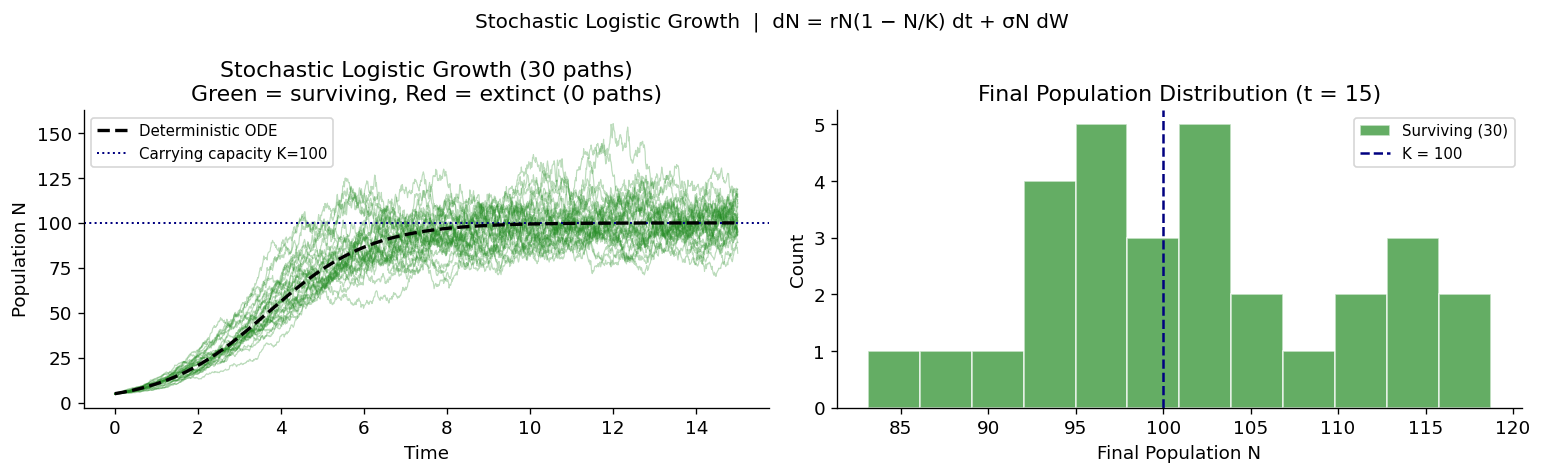

Survivors — Mean: 101.5, Std: 8.7


In [13]:
# --- Stochastic logistic parameters ---
r         = 0.8     # intrinsic growth rate
K         = 100.0   # carrying capacity
sigma_bio = 0.15    # environmental stochasticity

def logistic_drift(N, t):
    return r * N * (1.0 - N / K)

def logistic_diffusion(N, t):
    return sigma_bio * N  # multiplicative: scales with population size

# Simulate 30 paths from a small founder population
t_bio, N_paths = euler_maruyama(
    drift=logistic_drift,
    diffusion=logistic_diffusion,
    x0=5.0,       # 5 founding individuals
    t_start=0.0,
    t_end=15.0,
    dt=0.01,
    n_paths=30,
    seed=123
)

# Clip to 0 — extinction is absorbing
N_paths = np.clip(N_paths, 0, None)

# Count extinctions (final pop < 1)
n_extinct = np.sum(N_paths[:, -1] < 1.0)
print(f'Paths simulated: 30  |  Extinctions: {n_extinct}  |  Rate: {n_extinct/30*100:.1f}%')

# --- Deterministic reference ---
def logistic_ode(N0, r, K, t):
    """Analytical solution to the logistic ODE."""
    return K * N0 * np.exp(r * t) / (K + N0 * (np.exp(r * t) - 1))

t_det = np.linspace(0, 15, 500)
N_det = logistic_ode(5.0, r, K, t_det)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: all paths
for path in N_paths:
    color = 'crimson' if path[-1] < 1.0 else 'forestgreen'
    axes[0].plot(t_bio, path, alpha=0.3, linewidth=0.7, color=color)

axes[0].plot(t_det, N_det, color='black', linewidth=2.0,
             linestyle='--', label='Deterministic ODE', zorder=5)
axes[0].axhline(K, color='navy', linestyle=':', linewidth=1.2, label=f'Carrying capacity K={K:.0f}')
axes[0].set_title(f'Stochastic Logistic Growth (30 paths)\n'
                  f'Green = surviving, Red = extinct ({n_extinct} paths)')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Population N')
axes[0].legend(fontsize=9)

# Right: final population histogram
survivors = N_paths[:, -1][N_paths[:, -1] >= 1.0]
axes[1].hist(survivors, bins=12, color='forestgreen', alpha=0.7,
             edgecolor='white', label=f'Surviving ({len(survivors)})')
axes[1].axvline(K, color='navy', linestyle='--', linewidth=1.5, label=f'K = {K:.0f}')
if n_extinct > 0:
    axes[1].bar(0, n_extinct, width=4, color='crimson', alpha=0.7, label=f'Extinct ({n_extinct})')
axes[1].set_title('Final Population Distribution (t = 15)')
axes[1].set_xlabel('Final Population N')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=9)

plt.suptitle('Stochastic Logistic Growth  |  dN = rN(1 − N/K) dt + σN dW', fontsize=12)
plt.tight_layout()
plt.show()

if len(survivors) > 0:
    print(f'Survivors — Mean: {survivors.mean():.1f}, Std: {survivors.std():.1f}')

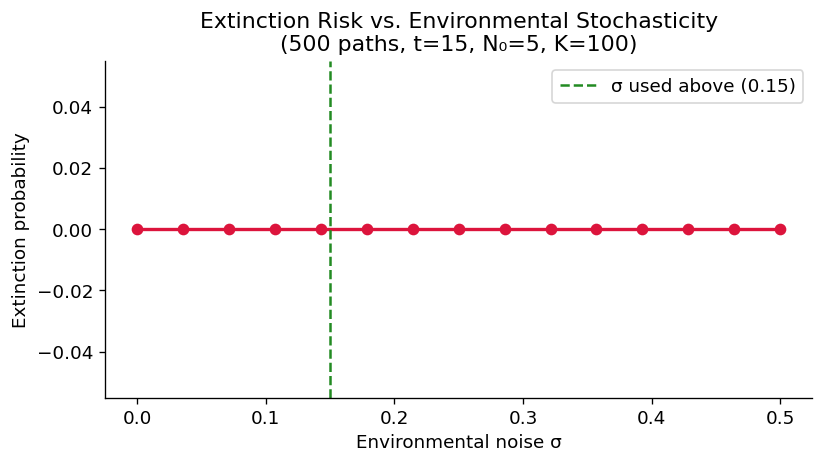

In [14]:
# --- Extinction probability vs noise level ---
# Run 500 paths across a range of σ values to show how noise drives extinction risk

sigma_range = np.linspace(0.0, 0.50, 15)
ext_rates = []

for sig in sigma_range:
    def ld(N, t): return r * N * (1.0 - N / K)
    def diff(N, t): return sig * N
    _, Np = euler_maruyama(ld, diff, x0=5.0, t_start=0, t_end=15,
                           dt=0.02, n_paths=500, seed=0)
    Np = np.clip(Np, 0, None)
    ext_rates.append((Np[:, -1] < 1.0).mean())

plt.figure(figsize=(7, 4))
plt.plot(sigma_range, ext_rates, 'o-', color='crimson', linewidth=2)
plt.axvline(sigma_bio, color='forestgreen', linestyle='--',
            linewidth=1.5, label=f'σ used above ({sigma_bio})')
plt.xlabel('Environmental noise σ')
plt.ylabel('Extinction probability')
plt.title('Extinction Risk vs. Environmental Stochasticity\n(500 paths, t=15, N₀=5, K=100)')
plt.legend()
plt.tight_layout()
plt.show()

**What to observe:**
- The deterministic ODE always predicts recovery to K — it knows nothing about extinction
- Even moderate noise creates non-zero extinction probability for small founder populations
- The extinction risk curve rises steeply — this is why conservation biologists care deeply about environmental variability

---
## 4. System 3 — Finance: Geometric Brownian Motion

**Models:** asset prices (foundation of Black-Scholes)

$$dS = \mu S\, dt + \sigma S\, dW$$

| Symbol | Meaning |
|--------|---------|
| $\mu$ | Drift — expected return (e.g. 8% p.a.) |
| $\sigma$ | Volatility — std of returns (e.g. 20% p.a.) |
| $S\,dW$ | **Multiplicative noise** — price shocks proportional to price level |

The analytical solution is:

$$S(T) = S_0 \exp\!\left[\left(\mu - \tfrac{\sigma^2}{2}\right)T + \sigma W(T)\right]$$

Note the $-\sigma^2/2$ **Itô correction** — this is where Itô's lemma shows up in practice.

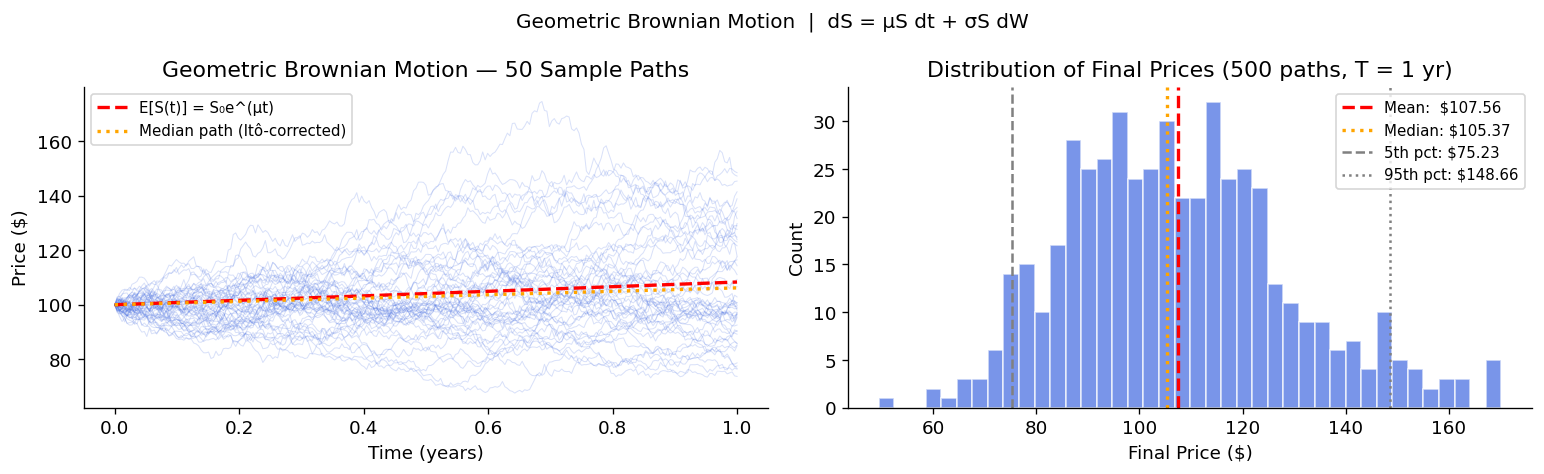

GBM after 1 year (500 paths):
  Starting price:        $100.00
  Mean final price:      $107.56  (theoretical: $108.33)
  Median:                $105.37  (theoretical: $106.18)
  5th percentile (VaR):  $75.23
  95th percentile:       $148.66
  Prob(S > $100):        60.4%


In [15]:
# --- GBM parameters ---
mu_fin    = 0.08    # 8% annual expected return
sigma_fin = 0.20    # 20% annual volatility
S0        = 100.0   # initial price

def gbm_drift(S, t):
    return mu_fin * S

def gbm_diffusion(S, t):
    return sigma_fin * S

# Simulate 500 paths over 1 year (252 trading-day steps)
t_fin, S_paths = euler_maruyama(
    drift=gbm_drift,
    diffusion=gbm_diffusion,
    x0=S0,
    t_start=0.0,
    t_end=1.0,
    dt=1/252,
    n_paths=500,
    seed=7
)

# Analytical quantities
mean_path    = S0 * np.exp(mu_fin * t_fin)                      # E[S(t)] = S0 * e^(μt)
median_path  = S0 * np.exp((mu_fin - 0.5*sigma_fin**2) * t_fin) # median: Itô-corrected

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: 50 sample paths
for path in S_paths[:50]:
    axes[0].plot(t_fin, path, alpha=0.2, linewidth=0.6, color='royalblue')
axes[0].plot(t_fin, mean_path, color='red', linewidth=2,
             linestyle='--', label='E[S(t)] = S₀e^(μt)')
axes[0].plot(t_fin, median_path, color='orange', linewidth=2,
             linestyle=':', label='Median path (Itô-corrected)')
axes[0].set_title('Geometric Brownian Motion — 50 Sample Paths')
axes[0].set_xlabel('Time (years)')
axes[0].set_ylabel('Price ($)')
axes[0].legend(fontsize=9)

# Right: final price distribution
final_prices = S_paths[:, -1]
axes[1].hist(final_prices, bins=40, color='royalblue', alpha=0.7, edgecolor='white')
axes[1].axvline(final_prices.mean(),             color='red',    linestyle='--', linewidth=2,
                label=f'Mean:  ${final_prices.mean():.2f}')
axes[1].axvline(np.median(final_prices),          color='orange', linestyle=':',  linewidth=2,
                label=f'Median: ${np.median(final_prices):.2f}')
axes[1].axvline(np.percentile(final_prices, 5),  color='gray',   linestyle='--', linewidth=1.5,
                label=f'5th pct: ${np.percentile(final_prices, 5):.2f}')
axes[1].axvline(np.percentile(final_prices, 95), color='gray',   linestyle=':',  linewidth=1.5,
                label=f'95th pct: ${np.percentile(final_prices, 95):.2f}')
axes[1].set_title('Distribution of Final Prices (500 paths, T = 1 yr)')
axes[1].set_xlabel('Final Price ($)')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=9)

plt.suptitle('Geometric Brownian Motion  |  dS = μS dt + σS dW', fontsize=12)
plt.tight_layout()
plt.show()

print('GBM after 1 year (500 paths):')
print(f'  Starting price:        ${S0:.2f}')
print(f'  Mean final price:      ${final_prices.mean():.2f}  '
      f'(theoretical: ${mean_path[-1]:.2f})')
print(f'  Median:                ${np.median(final_prices):.2f}  '
      f'(theoretical: ${median_path[-1]:.2f})')
print(f'  5th percentile (VaR):  ${np.percentile(final_prices, 5):.2f}')
print(f'  95th percentile:       ${np.percentile(final_prices, 95):.2f}')
print(f'  Prob(S > $100):        {(final_prices > 100).mean()*100:.1f}%')

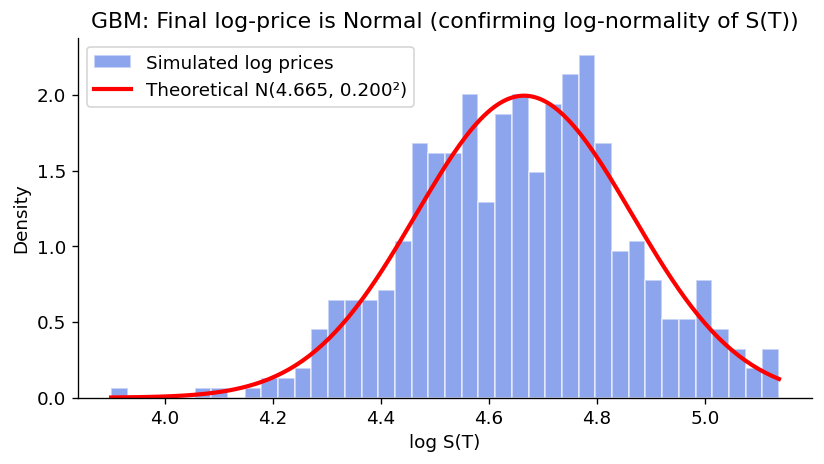

In [16]:
# --- Verify log-normality: log(S(T)) should be normally distributed ---
log_prices = np.log(final_prices)

# Theoretical parameters of the log-normal
mu_log_theory    = np.log(S0) + (mu_fin - 0.5 * sigma_fin**2) * 1.0
sigma_log_theory = sigma_fin * np.sqrt(1.0)

x_range = np.linspace(log_prices.min(), log_prices.max(), 200)
from scipy.stats import norm
pdf_theory = norm.pdf(x_range, mu_log_theory, sigma_log_theory)

plt.figure(figsize=(7, 4))
plt.hist(log_prices, bins=40, density=True, color='royalblue',
         alpha=0.6, edgecolor='white', label='Simulated log prices')
plt.plot(x_range, pdf_theory, 'r-', linewidth=2.5,
         label=f'Theoretical N({mu_log_theory:.3f}, {sigma_log_theory:.3f}²)')
plt.xlabel('log S(T)')
plt.ylabel('Density')
plt.title('GBM: Final log-price is Normal (confirming log-normality of S(T))')
plt.legend()
plt.tight_layout()
plt.show()

**Key observation:** Mean > Median for final prices — a direct consequence of log-normality. The few paths that shoot up dramatically pull the mean above the median. This is why "average return" ≠ "most likely outcome".

---
## 5. Convergence Analysis

The Euler-Maruyama method has **strong order 0.5** convergence:

$$\text{Error} \propto O(\sqrt{\Delta t})$$

To reduce the error by 10×, you need 100× smaller time steps.  
We verify this empirically using GBM, where the analytical mean is known: $\mathbb{E}[S(T)] = S_0 e^{\mu T}$

In [17]:
# Strong convergence test using shared Brownian motion (common random numbers).
# GBM has an analytical solution: S(T) = S0 · exp((μ − σ²/2)·T + σ·W(T))
# We generate the same Brownian increments for both EM and the exact solution,
# then measure the path-wise error E[|S_EM(T) − S_exact(T)|].
# This gives clean strong convergence O(√Δt) without sampling noise.

rng = np.random.default_rng(42)
n_paths_conv = 10_000
T_conv = 1.0
dt_values = [0.1, 0.05, 0.02, 0.01, 0.005, 0.001]
errors = []

print('Strong convergence test (GBM, shared Brownian paths):')
for dt in dt_values:
    N_steps = int(T_conv / dt)
    # Draw Brownian increments dW ~ N(0, dt) — shape: (n_paths, N_steps)
    dW = rng.normal(0, np.sqrt(dt), size=(n_paths_conv, N_steps))
    W_T = dW.sum(axis=1)  # total W(T) for each path

    # Exact GBM solution using the same W(T)
    S_exact = S0 * np.exp((mu_fin - 0.5*sigma_fin**2)*T_conv + sigma_fin*W_T)

    # Euler-Maruyama using the same increments
    S_em = np.full(n_paths_conv, S0, dtype=float)
    for i in range(N_steps):
        S_em = S_em + mu_fin*S_em*dt + sigma_fin*S_em*dW[:, i]

    err = np.mean(np.abs(S_em - S_exact))
    errors.append(err)
    print(f'  dt = {dt:.3f}  |  E[|S_EM − S_exact|] = {err:.5f}')

Strong convergence test (GBM, shared Brownian paths):
  dt = 0.100  |  E[|S_EM − S_exact|] = 0.76544
  dt = 0.050  |  E[|S_EM − S_exact|] = 0.54719
  dt = 0.020  |  E[|S_EM − S_exact|] = 0.34444
  dt = 0.010  |  E[|S_EM − S_exact|] = 0.24193
  dt = 0.005  |  E[|S_EM − S_exact|] = 0.17363
  dt = 0.001  |  E[|S_EM − S_exact|] = 0.07737


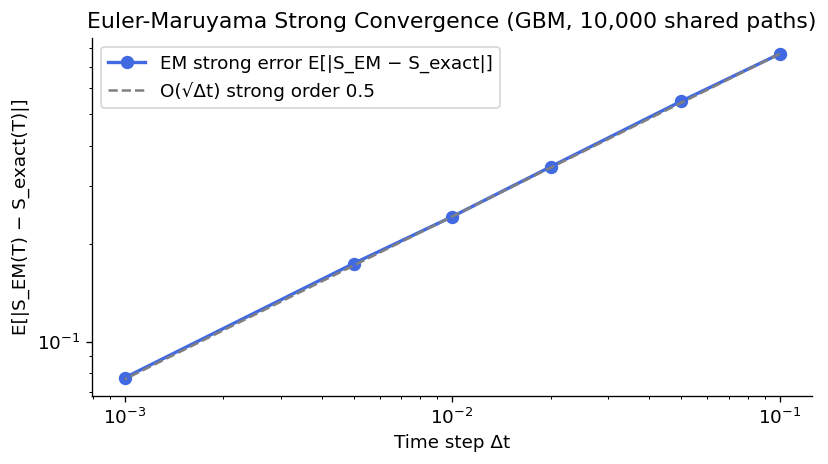

Empirical strong convergence order: 0.498  (theory: 0.5)


In [18]:
# Plot convergence on log-log scale
fig, ax = plt.subplots(figsize=(7, 4))

ax.loglog(dt_values, errors, 'o-', color='royalblue', linewidth=2,
          markersize=7, label='EM strong error E[|S_EM − S_exact|]')

# Reference O(√Δt) slope — strong order 0.5
ref = [errors[0] * np.sqrt(dt / dt_values[0]) for dt in dt_values]
ax.loglog(dt_values, ref, '--', color='gray', linewidth=1.5, label='O(√Δt) strong order 0.5')

ax.set_xlabel('Time step Δt')
ax.set_ylabel('E[|S_EM(T) − S_exact(T)|]')
ax.set_title('Euler-Maruyama Strong Convergence (GBM, 10,000 shared paths)')
ax.legend()
plt.tight_layout()
plt.show()

# Estimate empirical convergence order
log_dt = np.log(dt_values)
log_err = np.log(errors)
slope, intercept = np.polyfit(log_dt, log_err, 1)
print(f'Empirical strong convergence order: {slope:.3f}  (theory: 0.5)')

---
## 6. Putting It All Together — Side-by-Side Summary

A single comparison view of all three systems.

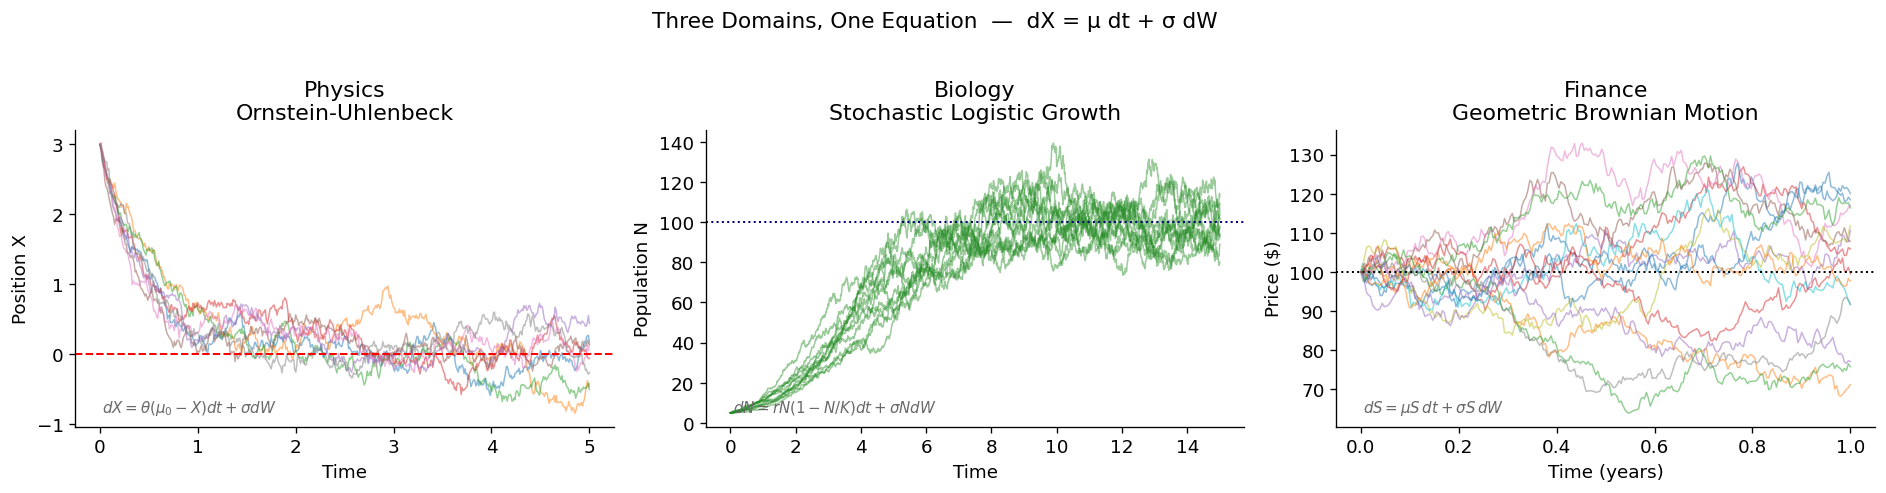

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- OU (Physics) ---
_, X_ou_plot = euler_maruyama(ou_drift, ou_diffusion, x0=3.0,
                               t_start=0, t_end=5.0, dt=0.01, n_paths=8, seed=42)
for p in X_ou_plot:
    axes[0].plot(np.arange(0, 5.0 + 0.01, 0.01), p, alpha=0.5, linewidth=0.9)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.2)
axes[0].set_title('Physics\nOrnstein-Uhlenbeck')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Position X')
axes[0].text(0.05, 0.05, r'$dX = \theta(\mu_0 - X)dt + \sigma dW$',
             transform=axes[0].transAxes, fontsize=9, color='dimgray')

# --- Stochastic logistic (Biology) ---
_, N_plot = euler_maruyama(logistic_drift, logistic_diffusion, x0=5.0,
                            t_start=0, t_end=15.0, dt=0.01, n_paths=12, seed=77)
N_plot = np.clip(N_plot, 0, None)
t_bio_plot = np.arange(0, 15.0 + 0.01, 0.01)
for p in N_plot:
    color = 'crimson' if p[-1] < 1 else 'forestgreen'
    axes[1].plot(t_bio_plot, p, alpha=0.45, linewidth=0.9, color=color)
axes[1].axhline(K, color='navy', linestyle=':', linewidth=1.2)
axes[1].set_title('Biology\nStochastic Logistic Growth')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Population N')
axes[1].text(0.05, 0.05, r'$dN = rN(1-N/K)dt + \sigma N dW$',
             transform=axes[1].transAxes, fontsize=9, color='dimgray')

# --- GBM (Finance) ---
_, S_plot = euler_maruyama(gbm_drift, gbm_diffusion, x0=S0,
                            t_start=0, t_end=1.0, dt=1/252, n_paths=15, seed=7)
t_fin_plot = np.arange(0, 1.0 + 1/252, 1/252)
for p in S_plot:
    axes[2].plot(t_fin_plot[:len(p)], p, alpha=0.5, linewidth=0.9)
axes[2].axhline(S0, color='black', linestyle=':', linewidth=1.2)
axes[2].set_title('Finance\nGeometric Brownian Motion')
axes[2].set_xlabel('Time (years)')
axes[2].set_ylabel('Price ($)')
axes[2].text(0.05, 0.05, r'$dS = \mu S\,dt + \sigma S\,dW$',
             transform=axes[2].transAxes, fontsize=9, color='dimgray')

plt.suptitle('Three Domains, One Equation  —  dX = μ dt + σ dW', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## Summary

| System | SDE | Drift | Diffusion | Domain |
|--------|-----|-------|-----------|--------|
| Ornstein-Uhlenbeck | $dX = \theta(\mu_0-X)dt + \sigma dW$ | Mean-reverting | Constant (additive) | Physics |
| Stochastic Logistic | $dN = rN(1-N/K)dt + \sigma N dW$ | Density-dependent | Multiplicative | Biology |
| Geometric BM | $dS = \mu S\,dt + \sigma S\,dW$ | Proportional growth | Multiplicative | Finance |

**The Euler-Maruyama recipe** (works for all three):
$$X_{n+1} = X_n + \mu(X_n,\, t_n)\cdot\Delta t + \sigma(X_n,\, t_n)\cdot\sqrt{\Delta t}\cdot Z_n, \quad Z_n\sim\mathcal{N}(0,1)$$

---

**Continue the series:**
- 📖 [Part 1 — Monte Carlo Integration in Python](https://thedataguy.pro/blog/2026/04/solving-integrals-sympy-monte-carlo/)
- 📖 [Part 2 — The Human History of Monte Carlo](https://thedataguy.pro/blog/2026/04/monte-carlo-history-discovery-evolution/)
- 📖 [Part 3 — This notebook](https://thedataguy.pro/blog/2026/04/stochastic-differential-equations-practitioners-guide/)

**Questions or feedback?** → [mo@thedataguy.pro](mailto:mo@thedataguy.pro) | [@TheDataGuyPro](https://twitter.com/TheDataGuyPro)